## Data Cleaning and Feature Engineering of Demand Test Dataset

**Updated April 8, 2026**

- Handle missing values: indicator features for missing values
- Standardize numeric features
- Cast boolean feautures
- Encode categorical features
    - Top K One-hot encode
    - For future steps: frequency encoding
- Encode time features: cyclical encoding


In [38]:
#### Setup

# Import libraries
import pandas as pd
import numpy as np

import re

import matplotlib.pyplot as plt

from pathlib import Path

In [39]:
# Load updated test dataset
DATA_PATH = Path("/Users/ethanc/RnA/data/testing_sample_raw.csv")
df = pd.read_csv(DATA_PATH)
print(df.shape)
print(df.columns)
df.head(3)

(1947, 42)
Index(['Unnamed: 0', 'eventid', 'event_date', 'number_of_shows', 'headliner',
       'support', 'venue', 'city', 'state', 'country', 'market',
       'company_type', 'currency', 'promoter', 'genre', 'avg_tickets_sold',
       'avg_gross_usd', 'avg_event_capacity', 'avg_capacity_sold',
       'ticket_price_min', 'ticket_price_max', 'ticket_price_avg',
       'avg_gross_usd_num', 'gt_avg_13w', 'gt_max_13w', 'gt_std_13w',
       'gt_momentum_13w', 'gt_date_range', 'wiki_avg_views_30d',
       'historical_concerts', 'day_of_week', 'month', 'year', 'season',
       'lockdown', 'last_album_date', 'days_since_last_album',
       'album_release_last_12m', 'Census_market_name', 'market_population',
       'past_year_avg_tickets', 'median_income'],
      dtype='object')


,Unnamed: 0,eventid,event_date,number_of_shows,headliner,support,venue,city,state,country,market,company_type,currency,promoter,genre,avg_tickets_sold,avg_gross_usd,avg_event_capacity,avg_capacity_sold,ticket_price_min,ticket_price_max,ticket_price_avg,avg_gross_usd_num,gt_avg_13w,gt_max_13w,gt_std_13w,gt_momentum_13w,gt_date_range,wiki_avg_views_30d,historical_concerts,day_of_week,month,year,season,lockdown,last_album_date,days_since_last_album,album_release_last_12m,Census_market_name,market_population,past_year_avg_tickets,median_income
0,1,ID0badbd5e13,2024-09-24,1,NCT Dream,NaN,Capital One Arena,Washington,District of Columbia,United States,"Washington, D.C. (Hagerstown)",Arena,US DOLLAR,Live Nation,Asian Pop,5879,949911.0,5879,100,59.5,199.5,161.58,949911.0,2.742376e-08,3.225806e-08,3.502638e-09,-7.825519e-09,2019-09-03 2024-10-01,765.333333,11,1,9,2024,fall,False,2023-07-17,435.0,0,"Washington-Arlington-Alexandria, DC-VA-MD-WV",6436489,8032.833333,123896.0
1,2,ID42a22a7467,2024-09-21,1,NCT Dream,NaN,UBS Arena,Belmont Park,New York,United States,New York,Arena,US DOLLAR,Live Nation,Asian Pop,7988,1264256.5,7988,100,53.5,193.5,158.27,1264256.5,2.768675e-08,3.225806e-08,3.219091e-09,-5.965573e-09,2019-09-03 2024-10-01,759.766667,10,5,9,2024,fall,False,2023-07-17,432.0,0,"New York-Newark-Jersey City, NY-NJ",19940274,8041.800000,97334.0
2,3,ID5120648c0a,2024-09-17,1,NCT Dream,NaN,Dickies Arena,Fort Worth,Texas,United States,Dallas-Ft. Worth,Arena,US DOLLAR,Live Nation,Asian Pop,7555,1025836.0,9130,82,59.5,199.5,135.78,1025836.0,2.768675e-08,3.225806e-08,3.219091e-09,-5.965573e-09,2019-09-03 2024-10-01,735.900000,9,1,9,2024,fall,False,2023-07-17,428.0,0,"Dallas-Fort Worth-Arlington, TX",8344032,8163.500000,87155.0


In [40]:
venue_fill = (
    df.groupby("venue")["avg_capacity_sold"]
    .nunique()
    .reset_index()
    .rename(columns={"avg_capacity_sold": "unique_values"})
)
print(f"Total venues: {venue_fill['venue'].nunique()}")
print(f"Venues with only 1 unique avg_capacity_sold: {(venue_fill['unique_values'] == 1).sum()}")
print(f"Venues with multiple values:                  {(venue_fill['unique_values'] > 1).sum()}")


Total venues: 838
Venues with only 1 unique avg_capacity_sold: 510
Venues with multiple values:                  328


In [41]:
# Add career age
career_age = pd.read_csv("/Users/ethanc/RnA/data/test_sample_cleaned_apr8.csv")['career_age']
df['career_age'] = career_age
df.head(3)

,Unnamed: 0,eventid,event_date,number_of_shows,headliner,support,venue,city,state,country,market,company_type,currency,promoter,genre,avg_tickets_sold,avg_gross_usd,avg_event_capacity,avg_capacity_sold,ticket_price_min,ticket_price_max,ticket_price_avg,avg_gross_usd_num,gt_avg_13w,gt_max_13w,gt_std_13w,gt_momentum_13w,gt_date_range,wiki_avg_views_30d,historical_concerts,day_of_week,month,year,season,lockdown,last_album_date,days_since_last_album,album_release_last_12m,Census_market_name,market_population,past_year_avg_tickets,median_income,career_age
0,1,ID0badbd5e13,2024-09-24,1,NCT Dream,NaN,Capital One Arena,Washington,District of Columbia,United States,"Washington, D.C. (Hagerstown)",Arena,US DOLLAR,Live Nation,Asian Pop,5879,949911.0,5879,100,59.5,199.5,161.58,949911.0,2.742376e-08,3.225806e-08,3.502638e-09,-7.825519e-09,2019-09-03 2024-10-01,765.333333,11,1,9,2024,fall,False,2023-07-17,435.0,0,"Washington-Arlington-Alexandria, DC-VA-MD-WV",6436489,8032.833333,123896.0,-0.952103
1,2,ID42a22a7467,2024-09-21,1,NCT Dream,NaN,UBS Arena,Belmont Park,New York,United States,New York,Arena,US DOLLAR,Live Nation,Asian Pop,7988,1264256.5,7988,100,53.5,193.5,158.27,1264256.5,2.768675e-08,3.225806e-08,3.219091e-09,-5.965573e-09,2019-09-03 2024-10-01,759.766667,10,5,9,2024,fall,False,2023-07-17,432.0,0,"New York-Newark-Jersey City, NY-NJ",19940274,8041.800000,97334.0,-0.952103
2,3,ID5120648c0a,2024-09-17,1,NCT Dream,NaN,Dickies Arena,Fort Worth,Texas,United States,Dallas-Ft. Worth,Arena,US DOLLAR,Live Nation,Asian Pop,7555,1025836.0,9130,82,59.5,199.5,135.78,1025836.0,2.768675e-08,3.225806e-08,3.219091e-09,-5.965573e-09,2019-09-03 2024-10-01,735.900000,9,1,9,2024,fall,False,2023-07-17,428.0,0,"Dallas-Fort Worth-Arlington, TX",8344032,8163.500000,87155.0,-0.952103


### Drop Uneccessary Features

In [42]:
df = df.drop(columns=["season","Unnamed: 0","currency","avg_gross_usd_num"])

In [43]:
import pandas as pd
import numpy as np

raw = pd.read_csv("/Users/ethanc/RnA/data/testing_sample_raw.csv")
raw['event_date'] = pd.to_datetime(raw['event_date'])
raw = raw.sort_values(['headliner', 'event_date']).reset_index(drop=True)

# Expanding median of this artist's past prices (shift(1) excludes current event → no leakage)
raw['artist_hist_median'] = (
    raw.groupby('headliner')['ticket_price_avg']
       .transform(lambda x: x.expanding().median().shift(1))
)
raw['artist_hist_count'] = (
    raw.groupby('headliner')['ticket_price_avg']
       .transform(lambda x: x.expanding().count().shift(1))
       .fillna(0).astype(int)
)

# Fallback 1: genre + market median (for artists with <3 prior events)
gm_median = (
    raw.groupby(['genre', 'market'])['ticket_price_avg']
       .median().rename('genre_market_median')
)
raw = raw.merge(gm_median, on=['genre', 'market'], how='left')

# Fallback 2: global median (for missing genre/market)
global_median = raw['ticket_price_avg'].median()

MIN_HIST = 3
raw['baseline_ticket_price'] = np.where(
    raw['artist_hist_count'] >= MIN_HIST,
    raw['artist_hist_median'],
    raw['genre_market_median'].fillna(global_median),
)

# Ratio: 1.0 = priced at baseline, 1.5 = 50% above, 0.7 = 30% discount
raw['price_premium'] = raw['ticket_price_avg'] / raw['baseline_ticket_price']

# Log version is symmetric (2x premium and 0.5x discount are equidistant from 0)
# Also matches the elasticity convention used elsewhere in your pipeline
raw['log_price_premium'] = np.log(raw['price_premium'].clip(lower=0.01))

print(raw['price_premium'].describe())
# Expect median ~1.0, most values in roughly [0.5, 2.0]

df['log_price_premium'] = raw['log_price_premium']
df['baseline_ticket_price'] = raw['baseline_ticket_price']



count    1947.000000
mean        1.064202
std         0.422324
min         0.009060
25%         0.882340
50%         1.000000
75%         1.157540
max         6.200000
Name: price_premium, dtype: float64


### Handle missing values

Here we impute missing values. Also, the presence of missing values may contain information, so we create indicator features for those with a significant missing portion (>2%). Venue, company type, and genre are categorical and will be encoded, but `days_since_last_album` and `median_income` need to be imputed.
- `is_missing_support`
- `is_missing_genre`
- `is_missing_album_dates`
- `is_missing_income`


In [44]:
# Get columns with missing values
nan_cols = df.isnull().sum()[lambda x: x > 0]

# Create a DataFrame with missing counts and percentage side by side
nan_summary = pd.DataFrame({
    "count": nan_cols,
    "freq (%)": round(100 * nan_cols / len(df), 2)
})
display(nan_summary)

,count,freq (%)
support,1356,69.65
venue,2,0.10
company_type,34,1.75
genre,157,8.06
last_album_date,190,9.76
days_since_last_album,190,9.76
median_income,46,2.36
career_age,300,15.41


In [45]:
# Create indicator features for missing values
df['is_missing_support'] = df['support'].isnull().astype(int)
df['is_missing_genre'] = df['genre'].isnull().astype(int)
df['is_missing_album_dates'] = df['last_album_date'].isnull().astype(int)

In [46]:
# Impute days since last album with average
df['days_since_last_album'] = df['days_since_last_album'].fillna(df['days_since_last_album'].mean())

### Remove data: Non-Musical Events

In [47]:
non_musical_genres = ['Comedy', 'Spoken Word', 'Theatrical', 'Tribute Acts', 'Family Entertainment']

# Remove non-musical events
df = df[~df['genre'].isin(non_musical_genres)]
df = df.reset_index(drop=True)
df.shape

(1808, 44)

### Standardize numeric features

Typical standardization is not necessary for XGBoost model, but we will also fit the data to other models.

In [48]:
# Continuous numeric features
cols_to_standardize = ['number_of_shows', 'avg_tickets_sold', 'avg_gross_usd',
       'avg_event_capacity', 'avg_capacity_sold', 'ticket_price_min',
       'ticket_price_max', 'ticket_price_avg',
       'gt_avg_13w', 'gt_max_13w', 'gt_std_13w', 'gt_momentum_13w',
       'wiki_avg_views_30d', 'historical_concerts', 'days_since_last_album',
       'market_population', 'past_year_avg_tickets', 'median_income', 'career_age', 'baseline_ticket_price',
    'log_price_premium']

# Save mean and std before standardizing so we can inverse-transform later
scaler_stats = {
    col: {"mean": float(df[col].mean()), "std": float(df[col].std())}
    for col in cols_to_standardize
}

import json
scaler_path = Path("/Users/ethanc/RnA/data/scaler_stats_apr8.json")
with open(scaler_path, "w") as f:
    json.dump(scaler_stats, f, indent=2)
print(f"Scaler stats saved to {scaler_path.resolve()}")

def standardize(X):
    return (X - X.mean()) / X.std()

df[cols_to_standardize] = df[cols_to_standardize].apply(standardize)

# Change year relative to first date in dataset
start_year = df['year'].min()
df['year_offset'] = df['year'] - start_year

Scaler stats saved to /Users/ethanc/RnA/data/scaler_stats_apr8.json


### Boolean Features

In [49]:
# Ensure all boolean cols are 0/1

def cast_bools(df):
    bool_cols = df.select_dtypes(include="bool").columns.tolist()
    if bool_cols:
        df[bool_cols] = df[bool_cols].astype(int)
    return df, bool_cols

df, bool_cols = cast_bools(df)
print(bool_cols)

['lockdown']


### Categorical Features

In [50]:
cols_to_encode = ['headliner','support','venue','city','state','market',
                  'company_type','promoter','genre']

# Top K One-hot encode
TOP_K = 5

def clean_col_name(name):
    name = re.sub(r'\.', '', name)         # delete periods
    name = re.sub(r'[\s\-]+', '_', name)   # spaces & dashes → underscore
    name = re.sub(r'[^\w_]', '_', name)    # remove all remaining special chars
    name = re.sub(r'_+', '_', name)        # collapse multiple underscores
    name = name.strip('_')
    parts = name.split('_')
    parts = [p.lower() if p else p for p in parts]  # make entire word lowercase
    return '_'.join(parts)

def build_top_k_columns(df, cols, top_k):
    for col in cols:
        top_in_col = df[col].value_counts().nlargest(top_k).index.tolist()
        df[col + "_cleaned"] = df[col].apply(lambda x: x if x in top_in_col else "other")

    cleaned_cols = [c for c in df.columns if c.endswith("_cleaned")]

    # one-hot encode
    df = pd.get_dummies(
        df,
        columns=cleaned_cols,
        drop_first=False,
        dtype=int,
    )

    new_columns = df.columns
    rename_dict = {}
    for col in new_columns:
        cleaned_col = clean_col_name(col)
        if cleaned_col != col: # if col name was changed
            rename_dict[col] = cleaned_col
    df.rename(columns=rename_dict, inplace=True)

    return df

df = build_top_k_columns(df, cols_to_encode, top_k=TOP_K)

### Encode Time Features

Encoding time features as sine and cosine values so the model can learn cyclical patterns. Encoding as categorical features instead would lose information about the relationship between adjacent months, where a numeric value would not be appropriate and assume linear relationship.

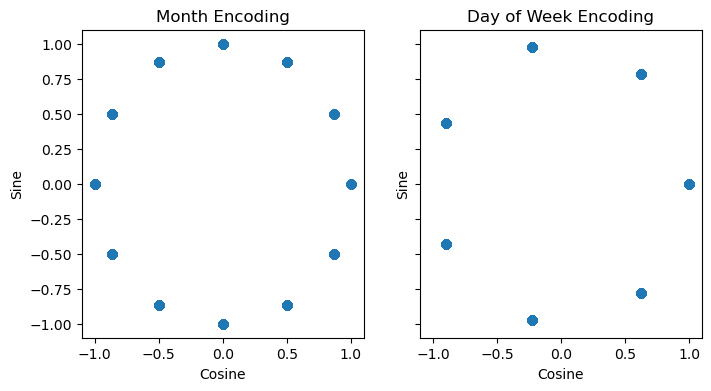

In [51]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Plot the results
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)
ax1.scatter(df['month_cos'], df['month_sin'])
ax1.set_title('Month Encoding')
ax2.scatter(df['day_of_week_cos'], df['day_of_week_sin'])
ax2.set_title('Day of Week Encoding')
for ax in [ax1, ax2]:
    ax.set_xlabel('Cosine')
    ax.set_ylabel('Sine')
plt.show()

### Verify Cleaning Results

In [52]:
pd.set_option('display.max_columns', None)

# Display first 5 rows
display(df.head(5))
# Print all columns
print(df.columns)

,eventid,event_date,number_of_shows,headliner,support,venue,city,state,country,market,company_type,promoter,genre,avg_tickets_sold,avg_gross_usd,avg_event_capacity,avg_capacity_sold,ticket_price_min,ticket_price_max,ticket_price_avg,gt_avg_13w,gt_max_13w,gt_std_13w,gt_momentum_13w,gt_date_range,wiki_avg_views_30d,historical_concerts,day_of_week,month,year,lockdown,last_album_date,days_since_last_album,album_release_last_12m,census_market_name,market_population,past_year_avg_tickets,median_income,career_age,log_price_premium,baseline_ticket_price,is_missing_support,is_missing_genre,is_missing_album_dates,year_offset,headliner_cleaned_aventura,headliner_cleaned_christian_nodal,headliner_cleaned_david_foster,headliner_cleaned_lord_huron,headliner_cleaned_randall_king,headliner_cleaned_other,support_cleaned_alex_fernández,support_cleaned_brandi_carlile_grouplove_kid_cut_up,support_cleaned_emo_philips,support_cleaned_erin_rae,support_cleaned_katharine_mcphee,support_cleaned_other,venue_cleaned_9_30_club,venue_cleaned_city_winery_atlanta,venue_cleaned_city_winery_nyc,venue_cleaned_city_winery_nashville,venue_cleaned_thalia_hall,venue_cleaned_other,city_cleaned_boston,city_cleaned_chicago,city_cleaned_new_york,city_cleaned_portland,city_cleaned_washington,city_cleaned_other,state_cleaned_california,state_cleaned_florida,state_cleaned_massachusetts,state_cleaned_new_york,state_cleaned_texas,state_cleaned_other,market_cleaned_boston_manchester,market_cleaned_chicago,market_cleaned_los_angeles,market_cleaned_new_york,market_cleaned_washington_dc_hagerstown,market_cleaned_other,company_type_cleaned_amphitheatre,company_type_cleaned_arena,company_type_cleaned_auditorium_theatre,company_type_cleaned_club,company_type_cleaned_stadium,company_type_cleaned_other,promoter_cleaned_in_house_productions_city_winery,promoter_cleaned_in_house_promotion,promoter_cleaned_aeg_presents,promoter_cleaned_cárdenas_marketing_network_cmn,promoter_cleaned_live_nation,promoter_cleaned_other,genre_cleaned_country,genre_cleaned_dance_electronic,genre_cleaned_latin,genre_cleaned_pop_rock,genre_cleaned_rap_hiphop,genre_cleaned_other,month_sin,month_cos,day_of_week_sin,day_of_week_cos
0,ID0badbd5e13,2024-09-24,-0.19251,NCT Dream,NaN,Capital One Arena,Washington,District of Columbia,United States,"Washington, D.C. (Hagerstown)",Arena,Live Nation,Asian Pop,0.387887,0.456655,0.322590,0.919471,1.032057,0.493716,1.907539,-0.160256,-0.172999,-0.190879,0.012861,2019-09-03 2024-10-01,-0.126504,-0.775878,1,9,2024,0,2023-07-17,-0.466974,0,"Washington-Arlington-Alexandria, DC-VA-MD-WV",0.285038,0.675613,2.472602,-0.958801,1.396936,-0.310016,1,0,0,4,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,-1.0,-1.836970e-16,0.781831,0.623490
1,ID42a22a7467,2024-09-21,-0.19251,NCT Dream,NaN,UBS Arena,Belmont Park,New York,United States,New York,Arena,Live Nation,Asian Pop,0.707544,0.734636,0.637229,0.919471,0.765605,0.461027,1.845549,-0.160256,-0.172999,-0.190879,0.012862,2019-09-03 2024-10-01,-0.128918,-0.783688,5,9,2024,0,2023-07-17,-0.468690,0,"New York-Newark-Jersey City, NY-NJ",2.865251,0.676943,0.817408,-0.958801,1.844540,-0.310016,1,0,0,4,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,-1.0,-1.836970e-16,-0.974928,-0.222521
2,ID5120648c0a,2024-09-17,-0.19251,NCT Dream,NaN,Dickies Arena,Fort Worth,Texas,United States,Dallas-Ft. Worth,Arena,Live Nation,Asian Pop,0.641915,0.523796,0.807603,0.253088,1.032057,0.493716,1.424350,-0.160256,-0.172999,-0.190879,0.012862,2019-09-03 2024-10-01,-0.139272,-0.791498,1,9,2024,0,2023-07-17,-0.470978,0,"Dallas-Fort Worth-Arlington, TX",0.649518,0.695001,0.183110,-0.958801,1.479993,-0.310016,1,0,0,4,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,-1.0,-1.836970e-16,0.781831,0.623490
3,ID3640ce7975,2024-09-14,-0.19251,NCT Dream,NaN,Oakland Arena,Oakland,California,United 

Index(['eventid', 'event_date', 'number_of_shows', 'headliner', 'support',
       'venue', 'city', 'state', 'country', 'market',
       ...
       'genre_cleaned_country', 'genre_cleaned_dance_electronic',
       'genre_cleaned_latin', 'genre_cleaned_pop_rock',
       'genre_cleaned_rap_hiphop', 'genre_cleaned_other', 'month_sin',
       'month_cos', 'day_of_week_sin', 'day_of_week_cos'],
      dtype='object', length=103)


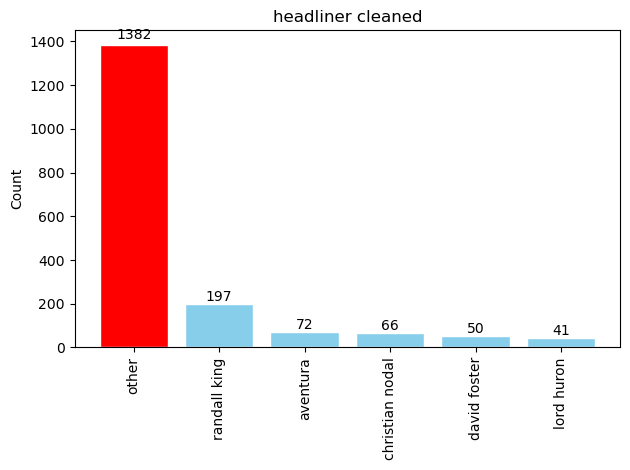

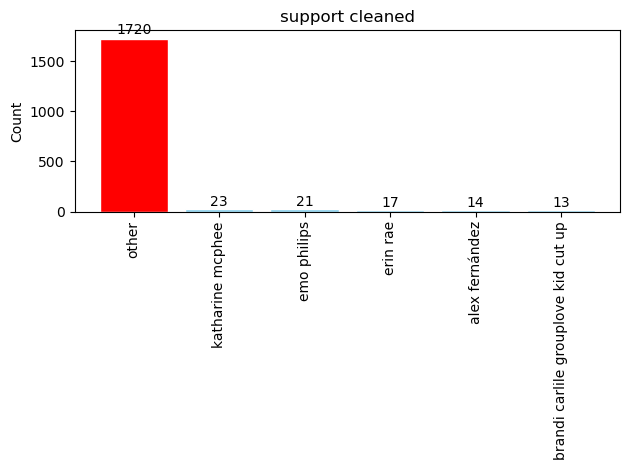

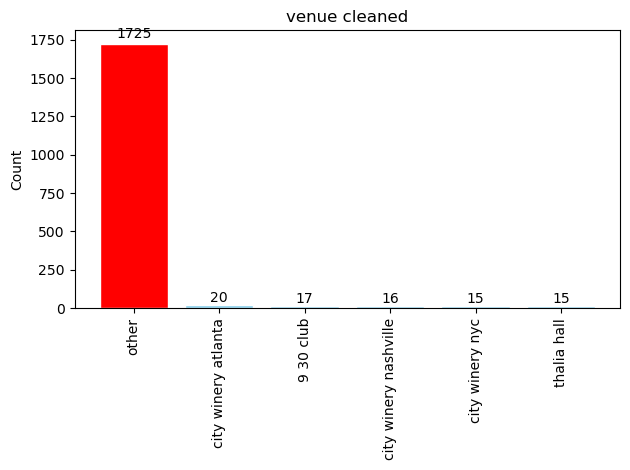

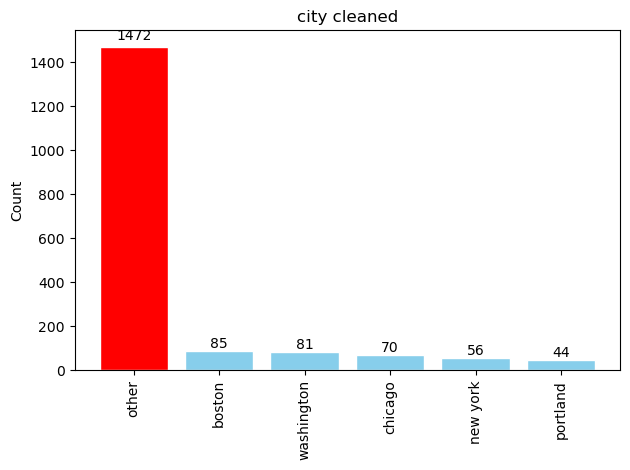

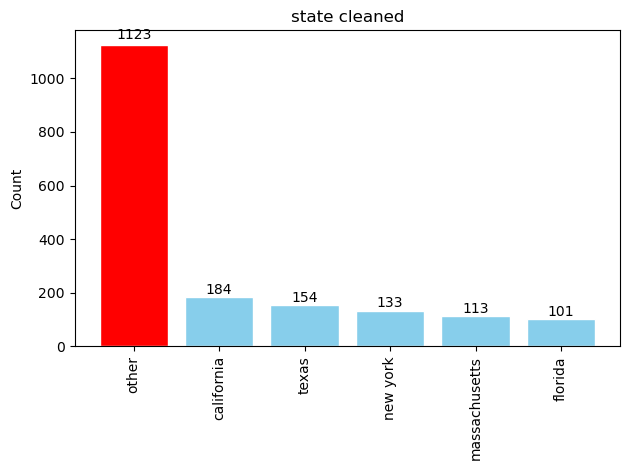

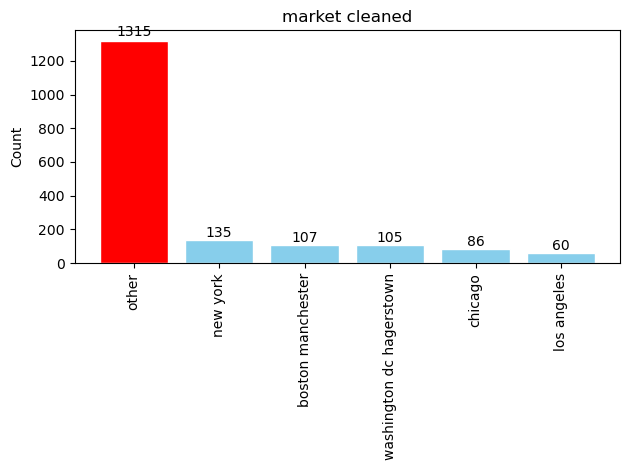

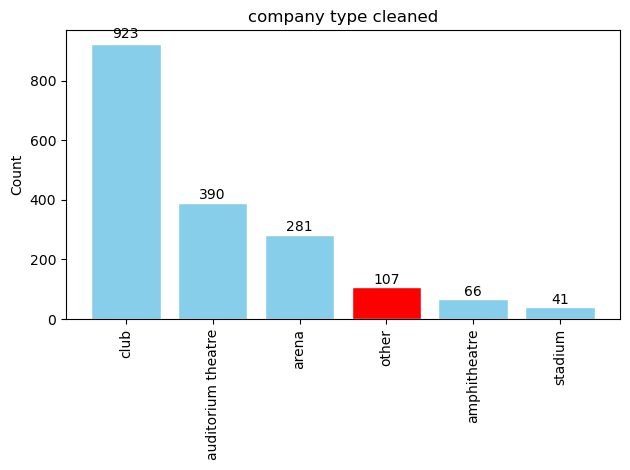

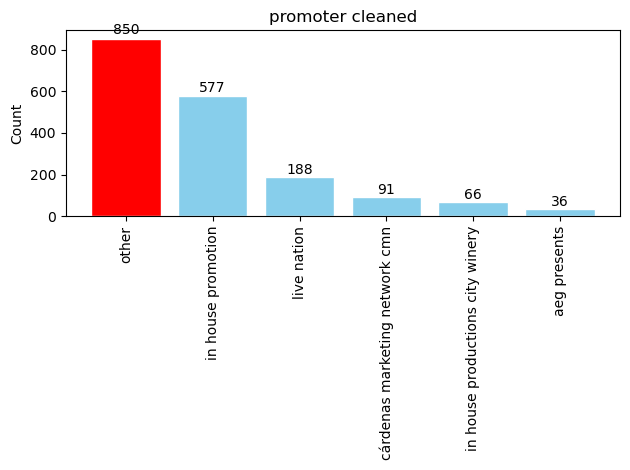

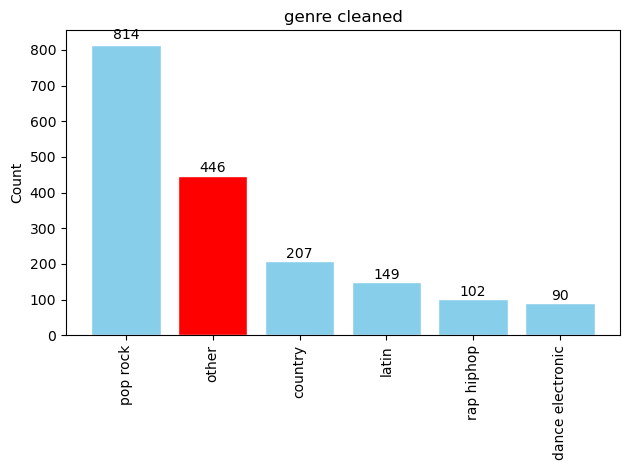

In [53]:
# Check what portion of each top K category is "other"

def plot_hist_top_k(prefix):

    # Get columns that start with the prefix
    cat_cols = [c for c in df.columns if c.startswith(prefix + "_")]
    if not cat_cols:
        print(f"No columns found for prefix: {prefix}")
        return
    cat_counts = df[cat_cols].sum().sort_values(ascending=False)
    cat_labels = [c.replace(prefix + "_", "").replace("_", " ") for c in cat_counts.index]

    # Function to make "other" category red
    def bar_colors(labels):
        return ["red" if l.strip().lower() == "other" else "skyblue" for l in labels]

    fig, ax = plt.subplots()
    ax.bar(cat_labels, cat_counts.values, color=bar_colors(cat_labels), edgecolor="white")
    ax.set_title(prefix.replace("_", " "))
    for i, v in enumerate(cat_counts.values):
        ax.text(i, v + 0.01 * v, str(v), ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=90)
    plt.tight_layout()
    plt.show()

for col in cols_to_encode:
    plot_hist_top_k(col + "_cleaned")

### Save

In [54]:
SAVE_PATH = Path("/Users/ethanc/RnA/data/test_sample_cleaned_v2.csv")
df.to_csv(SAVE_PATH, index=False)

In [55]:
nan_cols = df.isnull().sum()[lambda x: x > 0]

# Create a DataFrame with missing counts and percentage side by side
nan_summary = pd.DataFrame({
    "count": nan_cols,
    "freq (%)": round(100 * nan_cols / len(df), 2)
})
display(nan_summary)

,count,freq (%)
support,1238,68.47
venue,2,0.11
company_type,34,1.88
genre,157,8.68
last_album_date,70,3.87
median_income,46,2.54
career_age,285,15.76


###